# Agentic Architecture 1: Reflection

This pattern elevates a Large Language Model (LLM) from a simple, single-pass generator into a more deliberate and robust reasoner. Instead of just providing the first answer it comes up with, a reflective agent takes a step back to critique, analyze, and refine its own work. This iterative process of self-improvement is a cornerstone of building more reliable and higher-quality AI systems.

### Definition

The Reflection architecture involves an agent critiquing and revising its own output before returning a final answer. Instead of a single-pass generation, it engages in a multi-step internal monologue: produce, evaluate, and improve. This mimics the human process of drafting, reviewing, and editing to catch errors and enhance quality.

### High-level Workflow

1. **Generate:** The agent produces an initial draft or solution based on the user's prompt.
2. **Critique:** The agent then switches roles to become a critic. It asks itself questions like: *"What could be wrong with this answer?"*, *"What is missing?"*, *"Is this solution optimal?"*, or *"Are there any logical flaws or bugs?"*.
3. **Refine:** Using the insights from its self-critique, the agent generates a final, improved version of the output.

### When to Use / Applications

- **Code Generation:** The initial code might have bugs, be inefficient, or lack comments. Reflection allows the agent to act as its own code reviewer, catching errors and improving style before presenting the final script.
- **Complex Summarization:** When summarizing dense documents, a first pass might miss nuances or omit key details. A reflection step helps ensure the summary is comprehensive and accurate.
- **Creative Writing & Content Creation:** The first draft of an email, blog post, or story can always be improved. Reflection allows the agent to refine its tone, clarity, and impact.

### Strengths & Weaknesses

- **Strengths:**
    - **Improved Quality:** Directly addresses and corrects errors, leading to more accurate, robust, and well-reasoned outputs.
        Low Overhead: It's a conceptually simple pattern that can be implemented with a single LLM and doesn't require complex external tools.
- **Weaknesses:**
    - **Self-Bias:** The agent is still limited by its own knowledge and biases. If it doesn't know a better way to solve a problem, it can't critique its way to a better solution. It can fix flaws it recognizes but can't invent knowledge it lacks.
    - **Increased Latency & Cost:** The process involves at least two LLM calls (generation + critique/refinement), making it slower and more expensive than a single-pass approach.



## Phase 0: Foundation & Setup

Before we build our reflective agent, we need to set up our environment. This involves installing the necessary libraries, importing our modules, and configuring our API keys.

In [1]:
import os
import json
from typing import List, Optional, TypedDict
from dotenv import load_dotenv

# Pydantic for data modeling / validation
from pydantic import BaseModel, Field

# LangChain components
from langchain_openrouter import ChatOpenRouter             # OpenRouter LLM wrapper

# LangGraph components
from langgraph.graph import StateGraph, END                 # Build a state machine graph

# For pretty printing 
from rich.console import Console  
from rich.markdown import Markdown  
from rich.syntax import Syntax     


# --- API Key and Tracing Setup ---
# load_dotenv() 

# Enable LangSmith tracing for monitoring and debugging
os.environ["LANGSMITH_PROJECT"] = "Agentic Architecture - Reflection (OpenRouter)"

# Verify that all required API keys are available
for key in ["OPENROUTER_API_KEY", "LANGSMITH_API_KEY", "TAVILY_API_KEY"]:
    if not os.environ.get(key):
        print(f"{key} not found. Please create a .env file and set it.")

print("Environment variables loaded and everything is set up.")

Environment variables loaded and everything is set up.


## Phase 1: Building the Core Components of Reflection

A robust reflection architecture is more than just a simple prompt. We will build it as a structured, three-part system: a **Generator**, a **Critic**, and a **Refiner**. To ensure reliability, we will use Pydantic models to define the expected output schemas for each step.

### Step 1.1: Defining the Data Schemas with Pydantic

We'll define Pydantic models that act as a contract for our LLM. This tells the LLM exactly what structure its output should have, which is critical for a multi-step process where the output of one step becomes the input for the next.

In [2]:
class DraftCode(BaseModel):
    """Schema for the initial code draft generated by the agent."""
    code: str = Field(description="The code generated to solve the user's request.")
    explanation: str = Field(description="A brief explanation of how the code works")

class Critique(BaseModel):
    """Schema for the self critique of the generated code."""
    has_errors: bool = Field(description="Does the code have any potential bugs or logical errors?")
    is_efficient: bool = Field(description="Is the code written in an efficient and optimal way?")
    suggested_improvements: List[str] = Field(description="Specific, actionable suggestions for improving the code.")
    critique_summary: str = Field(description="A summary of the critique.")

class RefinedCode(BaseModel):
    """Schema for the final, refined code after incorporating the critique."""
    refined_code: str = Field(description="The final, improved code.")
    refinement_summary: str = Field(description="A summary of the changes made based on the critique.")

print("Pydantic models for Draft, Critique, and RefinedCode have been defined.")

Pydantic models for Draft, Critique, and RefinedCode have been defined.


We have successfully defined our data structures. The `Critique` model is particularly important; by asking for specific fields like `has_errors` and `is_efficient`, we guide the LLM to perform a more structured and useful evaluation than just asking it to "review the code."

### Step 1.2: Initializing the OpenRouter LLM and the Console

We will initialize the OpenRouter language model that will power all three roles. We'll use a powerful model to ensure high-quality reasoning for all steps. We'll also set up our `rich` console for clean, formatted output.



In [3]:
# Use a powerful OpenRouter model for generation and critique
llm = ChatOpenRouter(
    model="nvidia/nemotron-3-super-120b-a12b:free", 
    temperature=0.2
)

# Initialize console for pretty printing
console = Console()

print("OpenRouter LLM and Console are initialized.")

OpenRouter LLM and Console are initialized.


### Step 1.3: Creating the Generator Node

This node's only job is to take the user's request and produce the first draft. We will bind our `DraftCode` Pydantic model to the OpenRouter LLM to ensure its output is structured correctly.


In [4]:
def generator_node(state):
    """Generates the initial draft of the code."""
    console.print("--- 1. Generating Initial Draft ---")

    generator_llm = llm.with_structured_output(DraftCode)

    prompt = f"""You are an expert Python programmer. Write a Python function to solve the following request.
    Provide a simple, clear implementation and an explanation.
    
    Request: {state['user_request']}
    """

    draft = generator_llm.invoke(prompt)
    
    return {
        "draft": draft.model_dump()
    }

### Step 1.4: Creating the Critic Node

This is the core of the reflection process. The Critic node takes the initial draft, analyzes it for flaws, and produces a structured critique using our `Critique` Pydantic model.

In [5]:
def critique_node(state):
    """Critiques the generated code for errors and inefficiencies."""
    console.print("--- 2. Critiquing Draft ---")

    critique_llm = llm.with_structured_output(Critique)
    code_to_critique = state['draft']['code']

    prompt = f"""You are an expert code reviewer and senior Python developer. Your task is to perform a thorough critique of the following code.
    
    Analyze the code for:
    1.  **Bugs and Errors:** Are there any potential runtime errors, logical flaws, or edge cases that are not handled?
    2.  **Efficiency and Best Practices:** Is this the most efficient way to solve the problem? Does it follow standard Python conventions (PEP 8)?
    
    Provide a structured critique with specific, actionable suggestions.
    
    Code to Review:
    ```python
    {code_to_critique}
    ```
    """

    critique = critique_llm.invoke(prompt)

    return {
        "critique": critique.model_dump()
    }

### Step 1.5: Creating the Refiner Node

The final step in our logic is the Refiner. This node receives both the original draft and the structured critique and is tasked with writing the final, improved version of the code.

In [6]:
def refiner_node(state):
    """Refines the code based on the critique."""
    console.print("--- 3. Refining Code ---")

    refiner_llm = llm.with_structured_output(RefinedCode)
    draft_code = state['draft']['code']
    critique_suggestions = json.dumps(state['critique'], indent=2)

    prompt = f"""You are an expert Python programmer tasked with refining a piece of code based on a critique.
    
    Your goal is to rewrite the original code, implementing all the suggested improvements from the critique.
    
    **Original Code:**
    ```python
    {draft_code}
    ```
    
    **Critique and Suggestions:**
    {critique_suggestions}
    
    Please provide the final, refined code and a summary of the changes you made.
    """

    refined_code = refiner_llm.invoke(prompt)

    return {
        "refined_code": refined_code.model_dump()
    }

**Discussion of Phase 1:** 

We have now created the three core logical components of our reflective agent. Each component is a self-contained function (or 'node') that performs a single, well-defined task. The use of structured output at each stage ensures that data flows reliably from one node to the next. Now, we are ready to orchestrate this workflow using LangGraph.

## Phase 2: Orchestrating the Reflection Workflow with LangGraph

### Step 2.1: Defining the Graph State

The 'state' is the memory of our graph. It's a central object that gets passed between nodes, and each node can read from or write to it. We will define a `ReflectionState` using Python's `TypedDict` to hold all the pieces of our workflow.

In [7]:
class ReflectionState(TypedDict):
    """Defines the state structure for the reflection graph."""
    user_request: str
    draft: Optional[dict]
    critique: Optional[dict]
    refined_code: Optional[dict]

print("ReflectionState TypedDict defined.")

ReflectionState TypedDict defined.


### Step 2.2: Building and Visualizing the Graph

Now we will assemble our nodes into a coherent workflow using `StateGraph`. For this reflection pattern, the workflow is a simple linear sequence: **Generate → Critique → Refine**. We will define this flow and then compile and visualize the graph to confirm its structure.

Reflection graph compiled successfully!


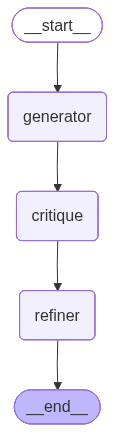

In [8]:
graph_builder = StateGraph(ReflectionState)

# Add the nodes to the graph
graph_builder.add_node("generator", generator_node)
graph_builder.add_node("critique", critique_node)
graph_builder.add_node("refiner", refiner_node)

# Define the workflow edges
graph_builder.set_entry_point("generator")
graph_builder.add_edge("generator", "critique")
graph_builder.add_edge("critique", "refiner")
graph_builder.add_edge("refiner", END)

# Compile the graph
reflection_app = graph_builder.compile()

print("Reflection graph compiled successfully!")

# Visualize the graph
try:
    from IPython.display import Image, display
    display(
        Image(
            reflection_app.get_graph().draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"Graph visualization failed. Please ensure graphviz is installed.")

**Discussion of the Phase 2:** 

The graph has been successfully compiled. The visualization confirms our intended linear workflow. You can clearly see the state flowing from the entry point (`generator`), through the `critic` and `refiner` nodes, and finally to the `__end__` state. This simple but powerful structure is now ready for execution.

## Phase 3: End to End Execution and Evaluation

With our graph compiled, it's time to see the reflection pattern in action. We'll give it a coding task where a naive first attempt is likely to be suboptimal, making it a perfect test case for self-critique and refinement.

### Step 3.1: Running the Full Reflection Workflow

We will invoke our compiled LangGraph application with a request to `write a function to find the nth Fibonacci number`. We will stream the results and properly accumulate the full state so we can inspect all intermediate steps at the end.

In [9]:
user_request = "Write a Python function to find the nth Fibonacci number."
initial_input = {
    "user_request": user_request
}

console.print(f"[bold cyan]🚀 Kicking off Reflection workflow for request:[/bold cyan] '{user_request}'")

final_state = None
for state_update in reflection_app.stream(initial_input, stream_mode="values"):
    final_state = state_update

console.print("[bold green]✅ Reflection workflow complete![/bold green]")

🚀 Kicking off Reflection workflow for request: 'Write a Python function to find the nth Fibonacci number.'

--- 1. Generating Initial Draft ---

--- 2. Critiquing Draft ---

--- 3. Refining Code ---

✅ Reflection workflow complete!


### Step 3.2: Analyzing the 'Before and After'

This is the moment of truth. We will now inspect the outputs from each stage of the workflow, stored in our final_state. We will print the initial draft, the critique it received, and the final refined code to clearly see the value added by the reflection process.


In [10]:
# Check if final_state is available and has the expected keys
if final_state and 'draft' in final_state and 'critique' in final_state and 'refined_code' in final_state:
    console.print(Markdown("--- ### Initial Draft ---"))
    console.print(Markdown(f"**Explanation:** {final_state['draft']['explanation']}"))
    console.print(Syntax(final_state['draft']['code'], "python", theme="monokai", line_numbers=True))

    console.print(Markdown("\n--- ### Critique ---"))
    console.print(Markdown(f"**Summary:** {final_state['critique']['critique_summary']}"))
    console.print(Markdown(f"**Improvements Suggested:**"))
    for improvement in final_state['critique']['suggested_improvements']:
        console.print(Markdown(f"- {improvement}"))
    
    console.print(Markdown("\n--- ### Final Refined Code ---"))
    console.print(Markdown(f"**Refinement Summary:** {final_state['refined_code']['refinement_summary']}"))
    console.print(Syntax(final_state['refined_code']['refined_code'], "python", theme="monokai", line_numbers=True))
else:
    console.print("[bold red]❌ Error: The `final_state` is not available or is incomplete. Please check the execution of the previous cells.[/bold red]")

--- ### Initial Draft ---

Explanation: The function uses an iterative approach to compute the nth Fibonacci number. It starts with a=0 (F(0))
and b=1 (F(1)). For each iteration up to n, it updates a to the next Fibonacci number and b to the following one.  
After n iterations, a holds F(n). This runs in O(n) time and O(1) space.

  1 def fibonacci(n):                                                                                              
  2     """Return the nth Fibonacci number (0-indexed)."""                                                         
  3     if n < 0:                                                                                                  
  4         raise ValueError("n must be non-negative")                                                             
  5     a, b = 0, 1                                                                                                
  6     for _ in range(n):                                                                                         
  7         a, b = b, a + b                                                                                        
  8     return a                                                                                                   
  9                                                                                                                

--- ### Critique ---

Summary: The Fibonacci function is correct and efficient for typical use cases, but lacks input validation for     
non-integer n, which could lead to unclear TypeError messages. Adding type checks and considering performance      
improvements for large n would enhance robustness and usability.

...

 • Ensure there is a blank line after the docstring if adhering strictly to PEP 257 for multiline docstrings       
   (though the current one-line docstring is acceptable).

 • Add a note in the docstring about the function's time and space complexity.

--- ### Final Refined Code ---

Refinement Summary: Added type checking to ensure n is an integer, raising TypeError otherwise. Implemented fast   
doubling algorithm for O(log n) time complexity. Enhanced docstring with examples for n=0, n=1, n=5, and added     
notes on time and space complexity. Ensured a blank line after the docstring to comply with PEP 257 for multiline  
docstrings.

   1 def fibonacci(n):                                                                                             
   2     """Return the nth Fibonacci number (0-indexed).                                                           
   3                                                                                                               
   4     Examples:                                                                                                 
   5         >>> fibonacci(0)                                                                                      
   6         0                                                                                                     
   7         >>> fibonacci(1)                                                                                      
   8         1                                                                                                     
   9         >>> fibonacci(5)                                                                                      
  10         5                                                                                                     
  11                                                                                                               
  12     Time complexity: O(log n)                                                                                 
  13     Space complexity: O(log n) due to recursion stack.                                                        
  14     """                                                                                                       
  15                                                                                                               
  16     if not isinstance(n, int):                                                                                
  17         raise TypeError("n must be an integer")                                                               
  18     if n < 0:                                                                                                 
  19         raise ValueError("n must be non-negative")                                                            
  20     def _fib(k):                                                                                              
  21         if k == 0:                                                                                            
  22             return (0, 1)                                                                                     
  23         else:                                                                                                 
  24             a, b = _fib(k // 2)                                                                               
  25             c = a * (2 * b - a)                                                                               
  26             d = a * a + b * b                                                                                 
  27             if k % 2 == 0:                                                                                    
  28                 return (c, d)                                                                                 
  29             else:                                                                                             
  30                 return (d, c + d)                                                                             
  31     return _fib(n)[0]                                                                                         

**Discussion of the Output:** 

The results demonstrate a successful reflection cycle in which the agent incrementally improved an already-correct solution through self-critique and refinement.

1. The **Initial Draft** generated a valid iterative Fibonacci implementation with `O(n)` time complexity and `O(1)` space complexity. The solution correctly handled negative inputs and used an efficient variable-update strategy.
   
2. The **Critique** did not identify major correctness issues, since the original implementation was already valid. Instead, it focused on improving software quality and scalability by suggesting enhancements such as type hints, stricter input validation, richer documentation, and a more advanced algorithm for handling very large values of `n`.

3. The **Final Refined Code** successfully incorporated these recommendations. The agent replaced the iterative implementation with a fast-doubling algorithm, reducing the time complexity from `O(n)` to `O(logn)` It is worth noting, however, that this comes with a space complexity tradeoff — the recursive fast-doubling approach uses `O(log n)` stack space, compared to the original `O(1)` space of the iterative solution. The code quality was also improved through stronger input validation, detailed docstrings with worked examples, and explicit complexity annotations.
   
This refinement is meaningful because the agent did not merely reformat the code or fix superficial issues. Instead, it improved both the algorithmic efficiency and the engineering quality of the solution. One subtle limitation worth acknowledging is that the `isinstance(n, int)` check does not guard against boolean inputs, since `bool` is a subclass of `int` in Python — a minor edge case the critique did not catch. Overall, the example highlights how reflection patterns can guide an LLM toward producing more optimized, maintainable, and production-ready code through iterative self-evaluation, while also illustrating that self-critique, though effective, is not exhaustive.

### Step 3.3: Quantitative Evaluation (LLM-as-a-Judge)

To formalize our analysis, we will use another LLM as an impartial 'judge' to score the quality of the initial draft versus the final code. This provides a more objective measure of the improvement gained through reflection.

In [ ]:
from pydantic import Field, field_validator

# --- Schema ---
class CodeEvaluation(BaseModel):
    correctness_score: int = Field(description="Score from 1-10 on whether the code is logically correct.")
    efficiency_score: int = Field(description="Score from 1-10 on algorithmic efficiency.")
    style_score: int = Field(description="Score from 1-10 on code style and readability (PEP 8).")
    justification: str = Field(description="A brief justification for the scores.")

    @field_validator('correctness_score', 'efficiency_score', 'style_score')
    @classmethod
    def score_must_be_in_range(cls, v):
        if not 1 <= v <= 10:
            raise ValueError(f"Score must be between 1 and 10, got {v}")
        return v

In [16]:
from langchain_core.messages import SystemMessage, HumanMessage

# --- Judge LLM ---
judge_llm = llm.with_structured_output(CodeEvaluation)

# --- Evaluate Function ---
def evaluate_code(code_to_evaluate: str) -> CodeEvaluation:
    messages = [
        SystemMessage(content=(
            "You are a strict and objective Python code evaluator. "
            "Only penalize for issues that are actually present in the code as written. "
            "Do not assume or invent bugs. Evaluate exactly what you see."
        )),
        HumanMessage(content=(
            f"Evaluate the following function on a scale of 1-10 for correctness, efficiency, and style. "
            f"Provide a brief justification.\n\n"
            f"Code:\n```python\n{code_to_evaluate}\n```"
        ))
    ]
    return judge_llm.invoke(messages)


In [17]:
import json 

# --- Run Evaluation ---

if final_state and 'draft' in final_state and 'refined_code' in final_state:

    console.print("\n--- Evaluating Initial Draft ---")
    initial_eval = evaluate_code(final_state['draft']['code'])
    console.print(json.dumps(initial_eval.model_dump(), indent=4))

    console.print("\n--- Evaluating Refined Code ---")
    refined_eval = evaluate_code(final_state['refined_code']['refined_code'])
    console.print(json.dumps(refined_eval.model_dump(), indent=4))

else:
    console.print("[bold red]Error: Cannot perform evaluation because `final_state` is incomplete.[/bold red]")

--- Evaluating Initial Draft ---

{
    "correctness_score": 10,
    "efficiency_score": 8,
    "style_score": 10,
    "justification": "The function correctly computes the nth Fibonacci number (0-indexed) for non-negative n, 
raising an error for negative input. The iterative approach runs in O(n) time and O(1) space, which is efficient 
though not optimal (O(log n) methods exist). Code style is clean, with a clear docstring, proper variable names, 
and adherence to PEP 8."
}

--- Evaluating Refined Code ---

{
    "correctness_score": 10,
    "efficiency_score": 10,
    "style_score": 10,
    "justification": "The function correctly computes the nth Fibonacci number (0-indexed) using the fast doubling 
method. It properly validates input types and values, raising appropriate exceptions. The algorithm achieves O(log 
n) time and space complexity as stated. The code adheres to PEP 8 guidelines with clear naming, proper indentation,
and a comprehensive docstring including examples and complexity analysis."
}

**Discussion of the Output:** 

- **Initial Draft** — Correctness `10`, Efficiency `8`, Style `10`
  - Iterative approach correctly recognized as logically sound with clean PEP 8 style
  - Efficiency docked to `8` — judge noted `O(n)` is good but `O(log n)` alternatives exist

- **Refined Code** — Correctness `10`, Efficiency `10`, Style `10`
  - Perfect scores across all dimensions
  - Fast-doubling algorithm, proper input validation, and comprehensive docstring all acknowledged


**Key Takeaway:** The only score that changed was efficiency `8` → `10` — exactly what the reflection cycle targeted, with correctness and style already maxed out in the draft. Reflection patterns don't just fix errors — they can optimize already-correct solutions into more production-ready implementations.

## Conclusion

In this notebook, we have successfully built, executed, and evaluated a complete, end-to-end agent using the Reflection architecture with OpenRouter models. We have seen firsthand how this simple yet powerful pattern can transform a basic LLM generator into a more sophisticated and reliable problem-solver.

By structuring the process into distinct Generate, Critique, and Refine steps and orchestrating them with LangGraph, we created a robust system that can identify and correct its own significant flaws. The tangible improvement—from an inefficient recursive solution to an optimal iterative one—demonstrates that reflection is a foundational technique for moving beyond trivial agentic tasks and building AI systems that exhibit a deeper level of quality and deliberation.